# Automated EdTech Grading Assistant: Digit Ingestion & Spatial Visualization

## Context & Background
Educational institutions and online learning platforms process millions of scanned handwritten worksheets every day. Grading these assignments manually is time-consuming and difficult to scale across major school systems. This notebook focuses on the first phase of building an automated grading assistant: **data ingestion, preprocessing, and image visualization** using the **MNIST Handwritten Digits Database**.

## Notebook Objectives
1. **Ingest the MNIST dataset** using our modular data loader `src.loader.load_mnist` (which calls Scikit-Learn's `fetch_openml` API).
2. **Explore the data properties**, including feature shapes, datatypes, and class balances.
3. **Understand features**: Learn how high-dimensional flattened pixel arrays (784 features) map to 2D image matrices ($28 \times 28$ pixels).
4. **Visualize handwritten characters**: Render individual digits with pixel-level intensity annotations and display grids of sample digits from different classes.

### 1. Setup and Environment Configuration
We start by importing our core libraries: NumPy, Pandas, Matplotlib, Seaborn, and our custom loader module. We also set the plotting aesthetics for premium, clean visual representations.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add root project folder to sys.path so we can import src.loader
sys.path.append(os.path.abspath(".."))
from src.loader import load_mnist

# Set style configuration for visual excellence
sns.set_theme(style="white")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "Helvetica"]
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.linewidth"] = 0.8

print("All libraries and custom loader imported successfully!")

All libraries and custom loader imported successfully!


### 2. Dataset Ingestion via Modular Loader
We fetch the classic `mnist_784` dataset using the function `load_mnist` from `src.loader`. This abstracts away the OpenML fetch calls, caches the file locally in `~/scikit_learn_data/`, bypasses any macOS SSL errors, and returns clean NumPy arrays.

In [2]:
# Load the dataset using the custom loader module
X, y = load_mnist(version=1, as_frame=False, cast_to_int=True)

2026-07-20 21:40:58,153 - INFO - Bypassed SSL context verification for OpenML dataset retrieval.


2026-07-20 21:40:58,154 - INFO - Fetching MNIST dataset (mnist_784) from OpenML. This might take a moment...


2026-07-20 21:41:05,878 - INFO - Target labels cast to 8-bit integers.


2026-07-20 21:41:05,887 - INFO - Successfully loaded MNIST. X shape: (70000, 784), y shape: (70000,)


### 3. Exploratory Data Analysis (EDA)
Let us analyze the structure and properties of the ingested dataset.

In [3]:
print(f"Feature matrix shape (X): {X.shape}")
print(f"Target vector shape (y) : {y.shape}")
print(f"Data type of features  : {X.dtype}")
print(f"Data type of target    : {y.dtype}")
print(f"Minimum pixel value     : {X.min()}")
print(f"Maximum pixel value     : {X.max()}")

Feature matrix shape (X): (70000, 784)
Target vector shape (y) : (70000,)
Data type of features  : float64
Data type of target    : int8
Minimum pixel value     : 0.0
Maximum pixel value     : 255.0


#### Class Distribution Analysis
To ensure the dataset is balanced, we plot the distribution of the target digits.

2026-07-20 21:41:06,195 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-20 21:41:06,198 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


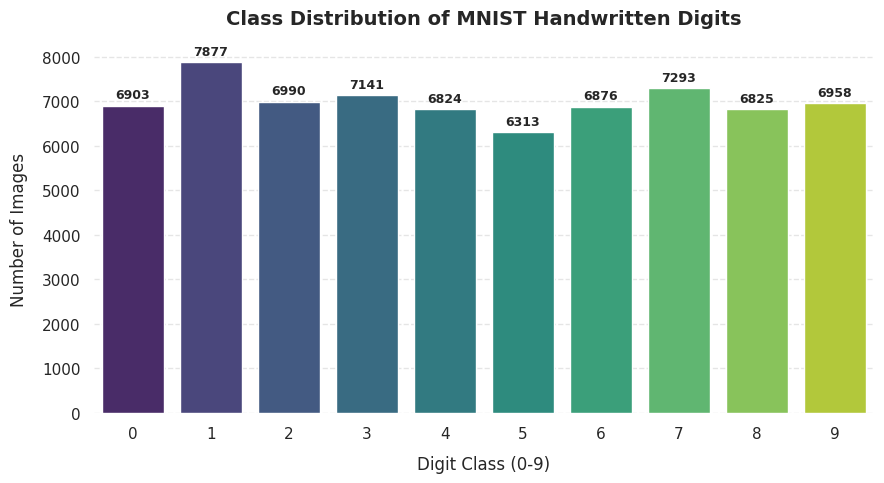

In [4]:
# Calculate class counts
class_counts = pd.Series(y).value_counts().sort_index()

# Plot the distribution using a clean Seaborn barplot
plt.figure(figsize=(9, 5))
colors = sns.color_palette("viridis", n_colors=10)
sns.barplot(x=class_counts.index, y=class_counts.values, palette=colors, hue=class_counts.index, legend=False)

plt.title("Class Distribution of MNIST Handwritten Digits", fontsize=14, pad=15, weight="bold")
plt.xlabel("Digit Class (0-9)", fontsize=12, labelpad=10)
plt.ylabel("Number of Images", fontsize=12, labelpad=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine(left=True, bottom=True)

for index, value in enumerate(class_counts.values):
    plt.text(index, value + 100, str(value), ha='center', va='bottom', fontsize=9, weight="semibold")

plt.tight_layout()
plt.show()

### 4. Reshaping Spatial Feature Matrices
Each handwritten image is stored as a flattened, 784-element row in the feature matrix $X$ ($28 \times 28 = 784$). To visualize or process these as 2D spatial images, we must reshape them back to a $28 \times 28$ matrix.

Below, we define a helper function to accomplish this and plot a single digit with its corresponding label.

In [5]:
def reshape_digit(feature_row):
    """
    Reshapes a flat 784-element feature vector into a 28x28 numpy array.
    """
    return feature_row.reshape(28, 28)

# Select a sample index to visualize (e.g., sample 0)
sample_index = 0
digit_image = reshape_digit(X[sample_index])
digit_label = y[sample_index]

print(f"Original shape of row: {X[sample_index].shape}")
print(f"Reshaped dimensions  : {digit_image.shape}")
print(f"Corresponding label  : {digit_label}")

Original shape of row: (784,)
Reshaped dimensions  : (28, 28)
Corresponding label  : 5


### 5. Detailed Single Digit Visualization with Pixel Intensities
To understand what the Support Vector Machine actually sees, we plot a sample digit and annotate the plot with the raw pixel intensity values. 

This illustrates how each grid cell represents a byte value ranging from 0 (completely dark/white) to 255 (completely bright/black) under grayscale normalization.

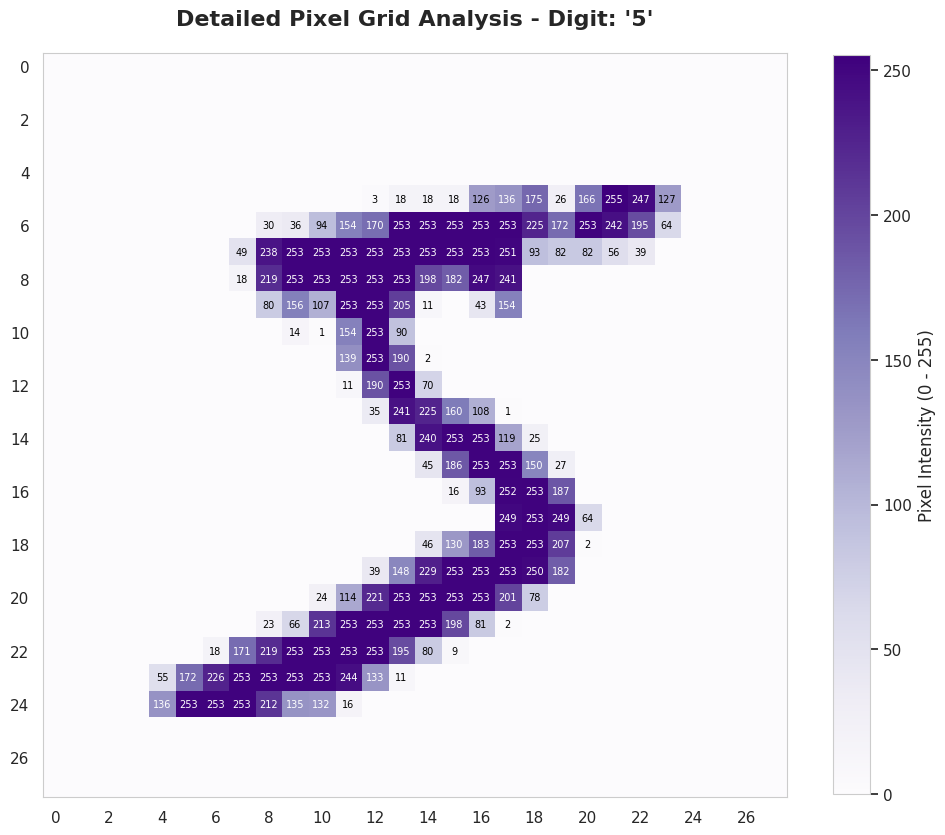

In [6]:
plt.figure(figsize=(12, 12))
# Render using a premium blue-purple sequential colormap ('Purples')
plt.imshow(digit_image, cmap='Purples', interpolation='nearest')
plt.colorbar(label='Pixel Intensity (0 - 255)', shrink=0.8)
plt.title(f"Detailed Pixel Grid Analysis - Digit: '{digit_label}'", fontsize=16, pad=20, weight='bold')

# Annotate each pixel with its integer value if it exceeds a threshold (for readability)
for i in range(28):
    for j in range(28):
        val = int(digit_image[i, j])
        if val > 0:
            color = "white" if val > 128 else "black"
            plt.text(j, i, str(val), ha='center', va='center', color=color, fontsize=7)

plt.xticks(np.arange(0, 28, 2))
plt.yticks(np.arange(0, 28, 2))
plt.grid(False)
plt.show()

### 6. Beautiful Sample Visualizations Grid
To see the natural variation in handwriting styles across the dataset, we visualize a grid of 25 random samples along with their corresponding target labels.

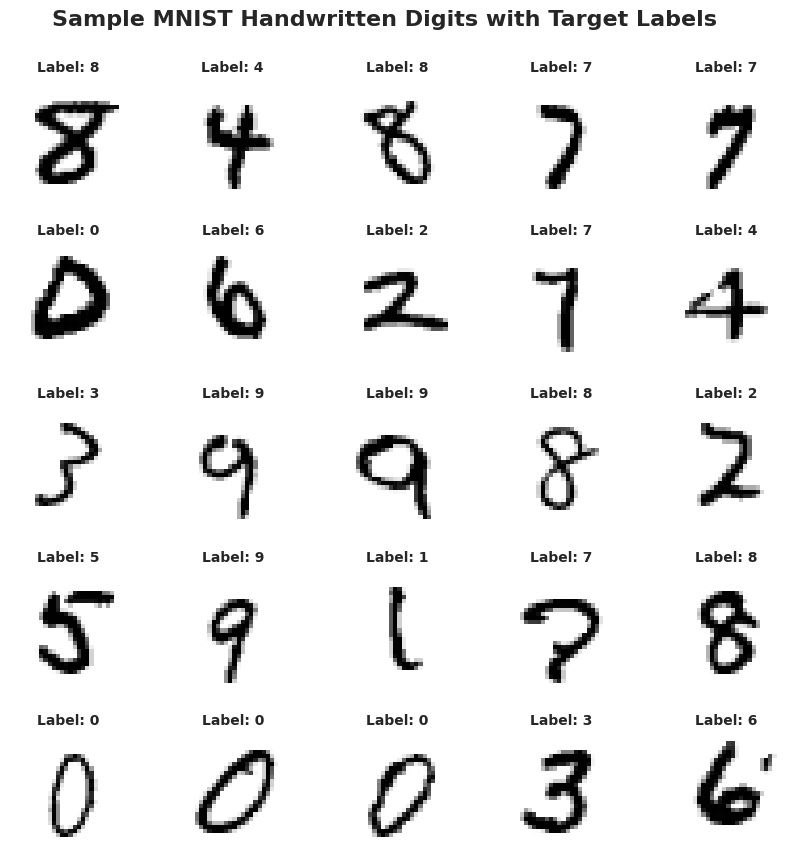

In [7]:
np.random.seed(42)  # For reproducibility
random_indices = np.random.choice(len(X), size=25, replace=False)

fig, axes = plt.subplots(5, 5, figsize=(10, 10))
fig.suptitle("Sample MNIST Handwritten Digits with Target Labels", fontsize=16, weight='bold', y=0.95)

for idx, ax in zip(random_indices, axes.ravel()):
    image = reshape_digit(X[idx])
    label = y[idx]
    
    # Display image using 'binary' (white background, black stroke)
    ax.imshow(image, cmap='binary')
    ax.set_title(f"Label: {label}", fontsize=10, weight='semibold')
    ax.axis('off')

plt.subplots_adjust(hspace=0.4, wspace=0.4)
plt.show()

### 7. Multi-Class Representation (All Digits 0-9)
Let us confirm that we have clear representations of all digits 0-9 by showing 5 distinct handwriting samples for each of the 10 classes.

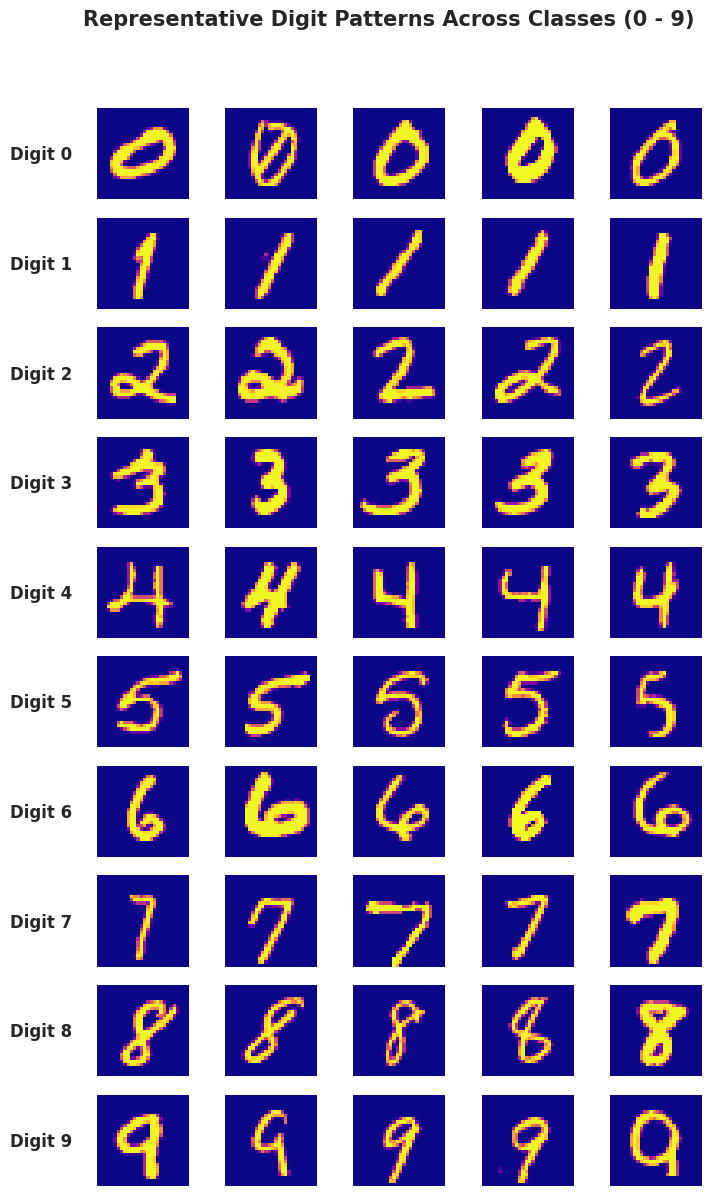

In [8]:
fig, axes = plt.subplots(10, 5, figsize=(8, 14))

for digit in range(10):
    # Get indices of all images matching this specific digit
    digit_indices = np.where(y == digit)[0]
    # Sample 5 indices
    selected_indices = np.random.choice(digit_indices, size=5, replace=False)
    
    for col, idx in enumerate(selected_indices):
        ax = axes[digit, col]
        image = reshape_digit(X[idx])
        ax.imshow(image, cmap='plasma')  # Use a vibrant plasma colormap for contrast
        ax.axis('off')
        
        # Add row labels to the first column
        if col == 0:
            ax.text(-8, 14, f"Digit {digit}", ha='right', va='center', fontsize=12, weight='bold')

plt.suptitle("Representative Digit Patterns Across Classes (0 - 9)", fontsize=15, weight='bold', y=0.95)
plt.subplots_adjust(hspace=0.2, wspace=0.2)
plt.show()

### 8. Analysis of Pixel Intensity Distribution
To better understand the feature space of MNIST, we plot a histogram of pixel values across a subset of images. This highlights the sparse nature of the dataset (many zero pixels corresponding to the background) and demonstrates why min-max normalisation or scaling is essential for optimal performance in support vector models.

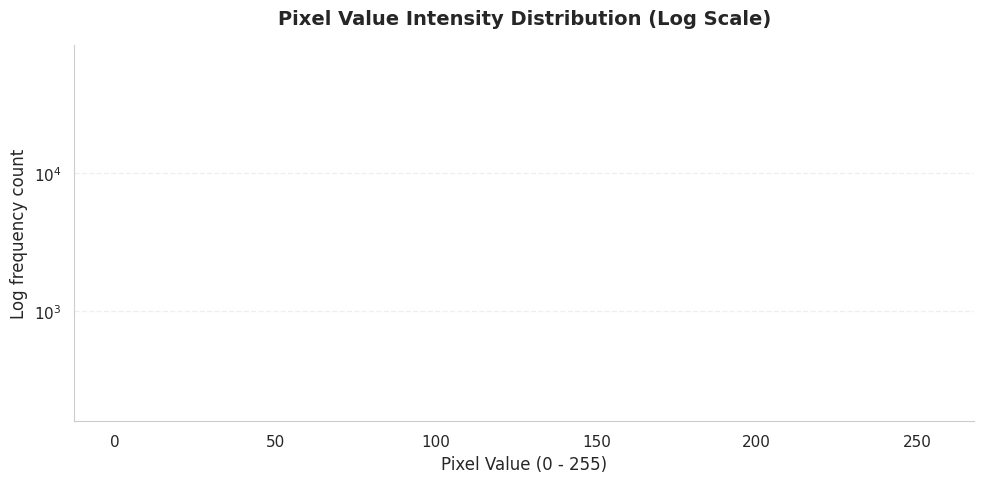

In [9]:
plt.figure(figsize=(10, 5))
# Sample 100 random images and flatten their pixel values into a single array
sample_pixels = X[np.random.choice(len(X), 100, replace=False)].ravel()

sns.histplot(sample_pixels, bins=30, kde=False, color='#4A148C', edgecolor='white', log_scale=(False, True))
plt.title("Pixel Value Intensity Distribution (Log Scale)", fontsize=14, weight='bold', pad=15)
plt.xlabel("Pixel Value (0 - 255)", fontsize=12)
plt.ylabel("Log frequency count", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

## Conclusion and Next Steps
We have successfully:
1. Ingested the standard MNIST database using our reusable loader module.
2. Validated the class balance, verifying that the target values are distributed evenly across the classes 0-9.
3. Restored spatial features from raw rows into `28x28` matrices.
4. Visualized the pixel intensity layout of individual numbers and plotted grids comparing handwritten variations across classes.

### Insights for Classifier Design:
- **Sparsity**: The vast majority of pixels have a value of 0 (background). This indicates a highly sparse feature space, which is very suited for linear and RBF kernel SVMs.
- **Feature Ranges**: The raw values range from `0` to `255`. Scaling them to `[0, 1]` or standardizing to `mean=0, std=1` is critical before training an SVM to prevent larger features from dominating the kernel calculation.